# Cosmologie avec les Supernovae 

Le but de ce TP est d'utiliser un jeu de données photométriques de [supernovae de type Ia](https://fr.wikipedia.org/wiki/Supernova_thermonucl%C3%A9aire) lointaines pour déterminer les paramètres cosmologiques de l'Univers.


![image de Riess, Perlmutter and Schmidt recevant le prix nobel](F1.medium.gif "Riess, Perlmutter and Schmidt recevant le prix nobel")

Les travaux pionniers sur le sujet ont permis de montrer que l'Univers subissait une accélération récente de son expansion.
En couplant ces résultats aux observations du fond diffus cosmologique qui fixent la plupart des paramètres cosmologiques, on conclut à la nécessité d'une force répulsive dont la densité d'énergie domine celles des autres composantes de l'Univers aujourd'hui.

Dans ce TP et le suivant, nous nous proposons de reproduire une part de l'analyse de ces données et d'apprendre comment sont produites les contraintes cosmologiques.

L'idée est d'exploiter l'observation empirique que la courbe de luminosité des explosions de supernovae de type Ia (figure **a** ci-dessous) suit, après étalonnage, une loi universelle (figure **b**) : l'observation de leur brillance au cours du temps permet de déterminer leur magnitude absolue (ou luminosité) et en fait d'excellentes [chandelles standard](https://fr.wikipedia.org/wiki/Chandelle_standard).

<img src="scale_curve.jpg" width="500px">

Ainsi, l'on peut déterminer pour chaque SNIa son [module de distance](https://fr.wikipedia.org/wiki/Module_de_distance) $\mu$ qui est la différence entre la magnitude apparente d'un objet $m$ et sa magnitude absolue $M$.
Cette différence, pour un objet de magnitude absolue donnée, est une fonction log-linéaire de la distance (dilution de la brillance par unité de surface en 1/$d^2$): si un objet est à la distance $d$ parsecs de nous, son module de distance est donc

$\mu = m - M = 5\log_{10}d - 5$

Par ailleurs, au moyen de la spectroscopie il est possible de mesurer précisément la vitesse d'expansion de l'univers via le [décalage vers le rouge](https://fr.wikipedia.org/wiki/D%C3%A9calage_vers_le_rouge) (ou *redshift*) de la supernova ou de sa galaxie hôte.

L'ensemble des modules de distance et décalages vers le rouge des différentes supernovae permet de construire un "diagramme de Hubble". Ce jeu de données peut être alors comparé à des prédictions issues de modèles et on peut ainsi déterminer les paramètres cosmologiques du modèle standard (Big-Bang) décrivant l'histoire de l'expansion de l'univers.

Le but de ce TP consiste donc à construire un diagramme de Hubble à partir d'un catalogue de données, puis à apprendre comment on peut utiliser ces données et un modèle théorique d'Univers pour contraindre les paramètres de celui-ci.

Dans un premier temps, nous travaillerons sur les données elles-mêmes afin d'apprendre à les manipuler et à calculer un modèle d'Univers qui cherche à reproduire les mesures obtenues.

Nous apprendrons ensuite à minimiser l'écart entre le modèle et les données, et à manipuler le $\chi^2$.

Dans le TP suivant nous adopterons une approche bayésienne qui nous permettra d'explorer la probabilité postérieure des paramètres cosmologiques et de combiner différents jeux de données afin de produire des contraintes plus fortes sur les modèles d'Univers.

In [33]:
import numpy as np
import scipy.stats as stats
import astropy.io.ascii as asciitable
import astropy.cosmology as cosmology
from matplotlib import pyplot as plt
import tp2 # fonctions déjà codées pour gagner du temps

## 1. Données

Nous utiliserons les données dites [Union2.1](http://supernova.lbl.gov/Union/) qui sont décrites ici :
[Suzuki et al. 2012, ApJ 746,85](http://adsabs.harvard.edu/cgi-bin/bib_query?arXiv:1105.3470). 

Ce catalogue contient pour chaque supernova : le module de distance et le décalage vers le rouge. 

Nous avons de plus accès à trois sources possibles pour les incertitudes du module de distance (le décalage vers le rouge est, lui,  mesuré avec une très grande précision):
* une colonne du catalogue `SCPUnion2.1_mu_vs_z.txt`  nommée 'distance_mod_err'; il s'agit uniquement des erreurs statistiques (imprécision de la photométrie),
* une matrice de covariance diagonale (fichier `SCPUnion2.1_covmat_nosys.txt`) contenant les mêmes valeurs que la colonne 'distance_mod_err' du catalogue, c'est-à-dire sans tenir compte des erreurs systématiques de mesure,
* une matrice de covariance non-diagonale (fichier `SCPUnion2.1_covmat_sys.txt`) tenant compte des erreurs systématiques et d'éventuelles corrélations entre ces erreurs. 

Explication: 
Les supernovae de la compilation Union2.1 sont issues de différents relevés.
Chaque relevé a son propre étalonnage, ses propres effets systématiques, et sa technique d'acquisition de données.
Tout cela induit des corrélations entre les magnitudes observées pour les différentes supernovae, et se traduit par une matrice de covariance non-diagonale.
C'est cette matrice complète qu'il convient en principe d'utiliser lorsque l'on compare les données à un modèle.

### 🏋 Exercices
1. Stocker dans une variable `catalogue` (en utilisant la fonction [`asciitable.read()`](https://docs.astropy.org/en/stable/api/astropy.io.ascii.read.html#astropy.io.ascii.read)) les données du catalogue.
1. Tracer le module de distance en fonction du décalage vers le rouge (diagramme de Hubble).
On pourra tracer (au moyen de [`plt.errorbar()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.errorbar.html)) les erreurs statistiques de mesure (colonne `distance_mod_err`) pour chaque point.
1. Comparer graphiquement et qualitativement (via [`plt.matshow()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.matshow.html)) les deux matrices de covariance fournies, stockées dans les variabes `nosys_covar_matrix` et `sys_covar_matrix`. Commenter ce que l'on observe.

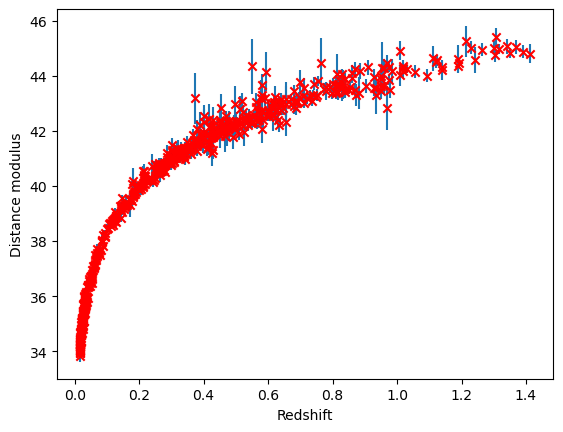

/tmp/ipykernel_39733/3919119621.py:21: RuntimeWarning: divide by zero encountered in log
  ax[0].matshow(np.log(nosys_covar_matrix))
/tmp/ipykernel_39733/3919119621.py:23: RuntimeWarning: invalid value encountered in log
  ax[1].matshow(np.log(sys_covar_matrix))


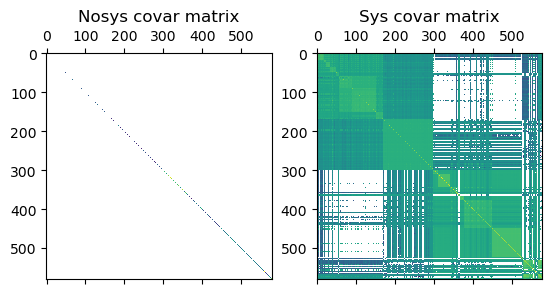

In [34]:
catalogue = asciitable.read("SCPUnion2.1_mu_vs_z.txt")
redshifts = [catalogue[k][1] for k in range(len(catalogue))]
distmodulus = [catalogue[k][2] for k in range(len(catalogue))]
errorsDM = [catalogue[k][3] for k in range(len(catalogue))]
plt.errorbar(redshifts,distmodulus,errorsDM,ls='none')
plt.scatter(redshifts,distmodulus,color='red',marker='x',zorder = 10)

plt.xlabel('Redshift')
plt.ylabel('Distance modulus')
plt.show()

fig,ax = plt.subplots(1,2)
nosys_covar_matrix = asciitable.read("SCPUnion2.1_covmat_nosys.txt")
sys_covar_matrix = asciitable.read("SCPUnion2.1_covmat_sys.txt")



nosys_covar_matrix = [[nosys_covar_matrix[k][l] for l in range(1,len(nosys_covar_matrix[1]))] for k in range(len(nosys_covar_matrix))]
sys_covar_matrix = [[sys_covar_matrix[k][l] for l in range(1,len(sys_covar_matrix[1]))] for k in range(len(sys_covar_matrix))]
from matplotlib.colors import LogNorm
ax[0].matshow(np.log(nosys_covar_matrix))
ax[0].title.set_text('Nosys covar matrix')
ax[1].matshow(np.log(sys_covar_matrix))
ax[1].title.set_text('Sys covar matrix')

plt.show()



## 2. Modèle physique

Pour modéliser ces données, il faut pouvoir prédire, pour chaque modèle cosmologique, le module de distance en fonction du décalage vers le rouge.

Pour cela nous utiliserons le module [astropy.cosmology](http://docs.astropy.org/en/stable/cosmology/index.html) *que nous vous encourageons à explorer.*

Pour commencer, nous utiliserons uniquement des modèles d'Univers plats, c'est à dire d'un Univers pour lequel la courbure de l'espace est nulle. Il se caractérise donc, dans le cadre des modèles de type Friedmann-Lemaître-Robertson-Walker, par des paramètres $\Omega_M$ et $\Omega_\Lambda$ (caractérisant les contenus en matière et en énergie sombre de l'univers) tels que $\Omega_M + \Omega_\Lambda = 1$.
Par ailleurs, le taux d'expansion de l'Univers caractérisé par la constante de Hubble $H_0$ est aujourd'hui encore imparfaitement connu.

Ces trois paramètres ont a priori une influence sur la relation entre la distance en luminosité (celle intervenant dans le module de distance des supernovae) et le décalage vers le rouge.

### Exercices
1. Tracer le module de distance $\mu$ en fonction du décalage vers le rouge $z$ pour un modèle cosmologique plat avec $H_0$ = 70 km/s/Mpc et $\Omega_M = 1$, en représentant les données sur le même graphique.
On utilisera l'objet [`FlatLambdaCDM`](https://docs.astropy.org/en/stable/api/astropy.cosmology.FlatLambdaCDM.html) du module [`astropy.cosmology`](https://docs.astropy.org/en/stable/cosmology/index.html) : une fois initialisé avec des valeurs des paramètres cosmologiques, sa méthode `distmod()` permet de calculer directement le module de distance en fonction du décalage vers le rouge.
1. Explorer graphiquement l'influence sur la courbe $\mu(z)$ de $H_0$ et de $\Omega_M$ lorsqu'ils s'écartent des valeurs précédentes, toujours pour un Univers plat (c'est à dire tel que $\Omega_M + \Omega_\Lambda = 1$, qui est modélisé par la routine `FlatLambdaCDM`).

-inf


/usr/lib/python3/dist-packages/astropy/cosmology/flrw/base.py:1352: RuntimeWarning: divide by zero encountered in log10
  val = 5.0 * np.log10(abs(self.luminosity_distance(z).value)) + 25.0


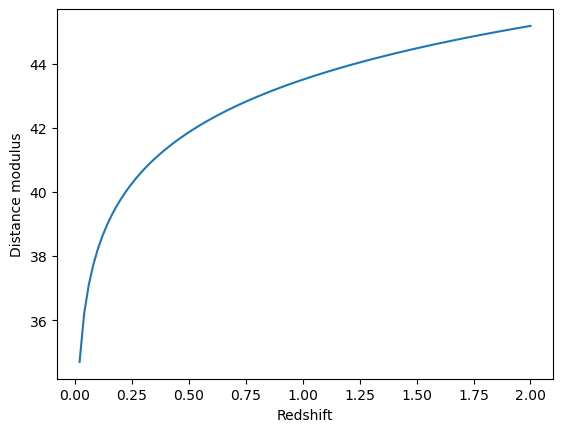

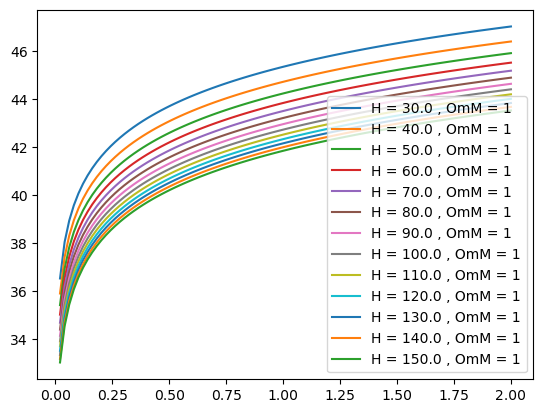

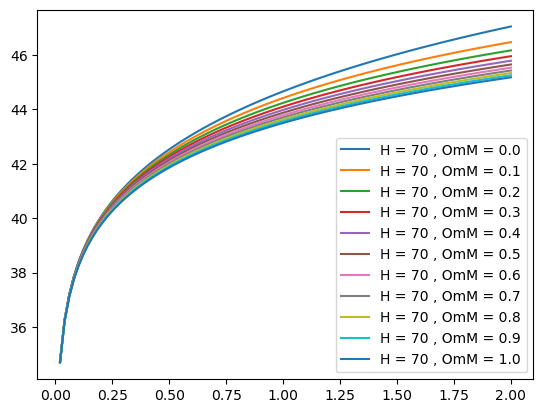

In [35]:
from astropy.cosmology import FlatLambdaCDM
lcdm = FlatLambdaCDM(70,1)
redshiftArray = np.linspace(0,2,100)
distmodArray = [lcdm.distmod(z).value for z in redshiftArray]
print(distmodArray[0])
plt.plot(redshiftArray,distmodArray)
plt.xlabel('Redshift')
plt.ylabel('Distance modulus')
plt.show()

listH = np.linspace(30,150,13)
for h in listH:
    lcdm = FlatLambdaCDM(h,1)
    distmodArray = [lcdm.distmod(z).value for z in redshiftArray]
    plt.plot(redshiftArray,distmodArray,label=f"H = {h} , OmM = 1")
plt.legend()
plt.show()

listO = [k*0.1 for k in range(11)]
for om in listO:
    lcdm = FlatLambdaCDM(70,om)
    distmodArray = [lcdm.distmod(z).value for z in redshiftArray]
    plt.plot(redshiftArray,distmodArray,label=f"H = 70 , OmM = {np.round(10*om)/10}")
plt.legend()
plt.show()



## 3. Modèle de bruit et $\chi^2$

Dans toute la suite, nous supposerons que le "bruit" affectant les données, dû à l'imprécision des mesures, est additif et de loi gaussienne. 

En supposant que l'on connaisse parfaitement les paramètres $\boldsymbol{\theta}$ du modèle cosmologique,  l'erreur sur la mesure du ième module de distance $\mu_i$ correspondant au décalage vers le rouge $z_i$ est la différence entre cette mesure et sa prédiction $y(z_i,\boldsymbol{\theta})$.
La distribution de cette erreur étant gaussienne et de déviation standard (estimée par les observateurs) $\sigma_i$, nous pouvons écrire simplement la densité de probabilité de $\mu_i(z_i)$ pour la $i$ème observation

$ \displaystyle p(\mu_i; \boldsymbol{\theta}) \propto \exp \left (-\frac{(\mu_i-y(z_i,\boldsymbol{\theta}))^2}{2\sigma^2_i}\right)$.

Cependant les erreurs sont corrélées entre-elles; nous devons en tenir compte si nous voulons écrire la densité de probabilité d'observer le catalogue de SNIa, dont les modules ont été regroupés dans le vecteur $\boldsymbol{\mu}$.
Cette densité s'écrit donc
$\displaystyle p(\boldsymbol{\mu}; \boldsymbol{\theta}) \propto \exp \left (-\frac{1}{2} (\boldsymbol{\mu}-\boldsymbol{y}(\boldsymbol{\theta}))^\intercal \mathbf{C}^{-1} (\boldsymbol{\mu}-\boldsymbol{y}(\boldsymbol{\theta}))\right)$ 
où l'on a noté $\boldsymbol{y}(\boldsymbol{\theta})$ le vecteur des prédictions théoriques pour le modèle de paramètres $\boldsymbol{\theta}$ et $\mathbf{C}$ la matrice de covariance des erreurs étudiée à la question 1.3.
Dans le cas idéal cas d'erreurs non corrélées, cette matrice $\mathbf{C}$ est diagonale, d'éléments $1/\sigma_i^2$.

Nous pouvons maintenant considèrer $p(\boldsymbol{\mu}; \boldsymbol{\theta})$ non plus comme une fonction du vecteur observation, $\boldsymbol{\mu}$ mais comme une fonction des paramètres $\boldsymbol{\theta}$ du modèle à $\boldsymbol{\mu}$ donné. On appelle cette fonction $\cal{L}(\boldsymbol{\theta}|\boldsymbol{\mu})$, la [*vraisemblance*](http://www.astromatic.net/m2aais/notes/Estimators.html#fonction-de-vraisemblance). Le maximum de cette fonction est atteint lorsque la différence entre modèle et données, pondérée par la covariance des erreur, est minimale. 
Ceci survient lorsque le vecteur paramètre $\boldsymbol{\theta}$ est tel ($\hat{\boldsymbol{\theta}}$) que la fonction $\chi^2(\boldsymbol{\theta})$ atteint sa valeur minimale:

$ \displaystyle \chi^2 = (\boldsymbol{\mu}-\boldsymbol{y}(\hat{\boldsymbol{\theta}}))^\intercal \mathbf{C}^{-1} (\boldsymbol{\mu}-\boldsymbol{y}(\boldsymbol{\hat{\theta}}))$.

On nomme cette fonction de distance entre données et modèles un $\chi^2$ pour de bonnes raisons. Cette fonction, en tant qu'estimation des erreurs quadratiques supposées gaussiennes et normalisées en variance, peut être vue comme la somme des carrés de tirages gaussiens aléatoires indépendants.
Cette somme est donc elle-même une variable aléatoire de propriétés connues; elle suit [une loi de probabilité dite du $\chi^2$](https://fr.wikipedia.org/wiki/Loi_du_%CF%87%C2%B2).
Comme nous allons le voir, la valeur du $\chi^2$ minimisé permet de tirer des conclusions sur l'adéquation du modèle (données et erreurs) aux observations. 

Dans ce qui suit, nous allons apprendre à calculer et manipuler ce $\chi^2$.

In [36]:
# Inversion de la matrice de covariance et stockage des données
sys_covar_matrix = np.loadtxt('SCPUnion2.1_covmat_sys.txt') # sans correction des erreurs systématiques 
inv_covar = np.linalg.inv(sys_covar_matrix) # inverse de la matrice de covariance des erreurs à utiliser pour le chi^2
catalogue = asciitable.read('SCPUnion2.1_mu_vs_z.txt')
zs_data = catalogue['redshift']
distmod_data = catalogue['distance_modulus']

### Exercice
1. Ecrire une fonction qui calcule le $\chi^2$ pour un modèle cosmologique plat donné ($H_0$, $\Omega_M$)
1. Si l'on admet $H_0 = 70$ km/s/Mpc, tracer le $\chi^2$ en fonction de $\Omega_M$. 
1. Trouver le minimum de cette fonction (on pourra tabuler la fonction et trouver une valeur approchée du minimum grâce à la fonction `np.argmin`).
1. Evaluer [la valeur p](https://fr.wikipedia.org/wiki/Valeur_p) de ce modèle optimal.
La valeur p est le résultat de la fonction de survie `stats.chi2.sf()` pour le $\chi^2$ considéré, compte-tenu du [nombre de degrés de liberté](https://fr.wikipedia.org/wiki/Degr%C3%A9_de_libert%C3%A9_(statistiques)) (nombre de points de mesure - nombre de paramètres du modèle). 
La valeur p est ici la probabilité d'obtenir par tirage aléatoire selon la loi du $\chi^2$, une valeur de $\chi^2$ plus élevée que celui obtenu.
On considérera que si cette valeur est plus grande que, $\alpha =  5\%$, alors le modèle sera considéré comme statistiquement plausible compte tenu des données : on ne peut pas rejeter l'hypothèse nulle.
1. Ne pouvait-on pas prédire ce résultat en considérant uniquement le $\chi^2$ réduit ?

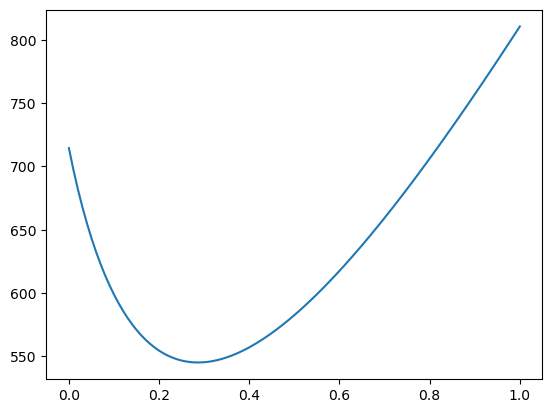

Chi2 minimal : 0.28500000000000003
nb de dfs : 579
P valeur associée 0.8395540184368168


In [37]:
def chi2lcdm(h,om):
    lcdm = FlatLambdaCDM(h,om)
    redshiftArray = zs_data.value
    predictionMod = [lcdm.distmod(z).value for z in redshiftArray]
    
    #plt.scatter(redshiftArray,predictionMod)
    aux = distmod_data.value - predictionMod
    chi2 = np.dot(inv_covar,aux)
    chi2 = np.dot(aux,chi2)
    return(chi2)

H0 = 70
chi2List = []
omlist = np.linspace(0,1,201)
chi2listStep = omlist[1]-omlist[0]
for om in omlist:
    chi2List.append(chi2lcdm(H0,om))
plt.plot(omlist,chi2List)
plt.show()
omOpti = omlist[np.argmin(chi2List)]
print(f'Chi2 minimal : {omOpti}')
pval = stats.chi2.sf(np.min(chi2List), len(catalogue)-1) # 1 DF puisque on n'optimise pas sur H0
print(f"nb de dfs : {len(catalogue)-1}")
print(f'P valeur associée {pval}')

# 5 : Je ne vois pas d'information qu'on perdrait avec le chi2 réduit, donc oui.


## 4. Vecteur paramètre

Dans les exercices précédents nous avons à chaque fois considéré que les paramètres cosmologiques se résument à un scalaire.
Nous allons maintenant nous intéresser au cas où l'on souhaite faire varier plusieurs paramètres à la fois, et étudier les éventuelles dépendances entre eux.

### Exercices
1. Adapter la routine $\chi^2$ pour qu'elle accepte une **liste** des 3 paramètres ($H_0$, $\Omega_M$, $\Omega_\Lambda$)
1. Tracer (avec [`plt.pcolor()`](https://matplotlib.org/api/_as_gen/matplotlib.pyplot.pcolor.html)) une carte du $\chi^2$ en fonction de ($\Omega_M$, $\Omega_\Lambda$) pour un $H_0$ donné.
1. Commenter le résultat. Les paramètres sont-ils indépendants ? Pourquoi ?
1. Pour quel point de l'espace des paramètres le minimum est-il atteint ?

Omega Matter optimal : 0.3061224489795918, Omega Dark optimal 0.7346938775510203; chi2 : 545.2293247161327


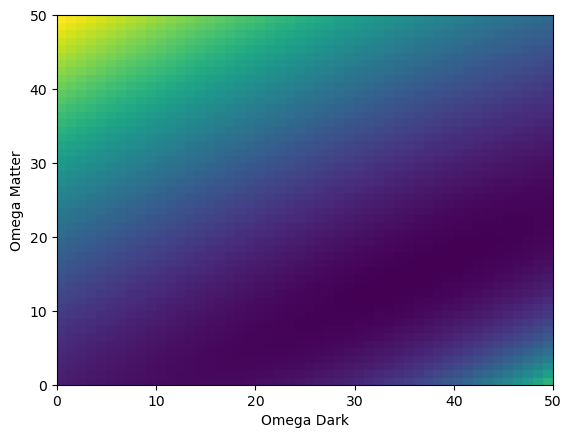

In [38]:
from astropy.cosmology import LambdaCDM

def chi2lcdm2(param):
    [h,om,ol] = param
    lcdm = LambdaCDM(h,om,ol)
    redshiftArray = zs_data.value
    predictionMod = [lcdm.distmod(z).value for z in redshiftArray]
    
    #plt.scatter(redshiftArray,predictionMod)
    aux = distmod_data.value - predictionMod
    chi2 = np.dot(inv_covar,aux)
    chi2 = np.dot(aux,chi2)
    return(chi2)

H0 = 70
nOm,nOl = 50,50
OmArray = np.linspace(0,1,nOm)
OlArray = np.linspace(0,1,nOl)
chi2Array = [[chi2lcdm2([H0,OmArray[k],OlArray[j]]) for j in range(len(OlArray))] for k in range(len(OmArray))]
print(f'Omega Matter optimal : {OmArray[np.argmin(chi2Array)//nOm]}, Omega Dark optimal {OlArray[np.argmin(chi2Array)%nOl]}; chi2 : {np.min(chi2Array)}')
plt.pcolor(chi2Array)
plt.xlabel("Omega Dark")
plt.ylabel("Omega Matter")
plt.show()

# Les paramètres sont clairement non indépendants

## 5. Discussion sur les probabilités, barres d'erreurs, et tracés 2D.

Dans une approche de type maximum de vraisemblance, on peut estimer l'incertitude sur les paramètres en utilisant une approximation gaussienne de la fonction de vraisemblance au pic.
L'incertitude est alors donnée par la déviation standard de cette gaussienne.

1. Utiliser la grille de l'exercice 3.2 (un seul paramètre : $\Omega_M$) pour déterminer la barre d'erreur sur $\Omega_M$ lorsque $H_0=70$ km/s/Mpc en utilisant une approximation gaussienne de la fonction de vraisemblance, et en calculant la dérivée seconde discrète du $\chi^2$ au pic de vraisemblance (on peut montrer, en passant par la log-vraisemblance, que $\sigma^2 = \frac{2}{d^2 \chi^2/d\theta^2}$).

2. Refaire une évaluation de $\sigma$ par une autre méthode (en fait équivalente, voir le cours) : cette fois en supposant que localement (autour du maximum de vraisemblance) le modèle est linéaire par rapport aux paramètres et qu'on peut donc estimer $\sigma$ par la région où $\chi^2 \le \chi^2_{pic} + 1$, car la différence $\chi^2 - \chi^2_{pic}$ suit alors en principe une loi du $\chi^2$ à un degré de liberté (car on n'a qu'un paramètre) et le 68e percentile de la fonction de répartition vaut alors `scipy.stats.chi2.ppf (0.68, 1) = 1`.

In [43]:
d1chi2List = np.gradient(chi2List,chi2listStep)
d2chi2List = np.gradient(d1chi2List,chi2listStep)
d2Opti = d2chi2List[np.argmin(chi2List)]
print(f"Derivée seconde à l'optimum de Chi2 {d2Opti}")
sigmaOm = np.sqrt(2/d2Opti)
print(f"L'erreur sur Om est {sigmaOm}")

Derivée seconde à l'optimum de Chi2 2185.7751820220983
L'erreur sur Om est 0.030249085716302568



3. Utiliser la grille de l'exercice 4.2 pour déterminer la matrice de variance-covariance des paramètres $\Omega_M$ et $\Omega_\Lambda$.
Il faut pour cela calculer numériquement [la matrice Hessienne](https://fr.wikipedia.org/wiki/Matrice_hessienne) de $\chi^2(\Omega_M, \Omega_\Lambda)$ au maximum de vraisemblance, qui donne à un facteur 2 près l'inverse de la matrice de covariance des paramètres (se rapporter au cas plus simple à un seul paramètre ci-dessus pour mieux comprendre).

4. Dans le cas d'une variable gaussienne **scalaire** $\theta$ centrée sur $\theta_0$ et de déviation standard $\sigma_\theta$, on sait calculer la probabilité $P_\sigma$ d'observer un tirage de la variable compris dans l'intervalle $\theta_0-\sigma_\theta < \theta < \theta_0 + \sigma_\theta$.
Cette probabilité s'obtient simplement en intégrant la loi de probabilité gaussienne dans l'intervalle considéré, si bien que
$\displaystyle P_{n\sigma} = \frac{1}{2} \left[ \mathrm{erf}\left(\frac{n}{\sqrt{2}}\right)-\mathrm{erf}\left(\frac{-n}{\sqrt{2}}\right) \right] = \mathrm{erf}\left(\frac{n}{\sqrt{2}}\right)$ qui vaut environ  $0.683$ pour $n=1$.
Calculer les probabilités $P_{2\sigma}$ et $P_{3\sigma}$ qu'un tirage gaussien scalaire tombe dans les intervalles $\pm 2\sigma$ et $\pm 3\sigma$, respectivement.

En anticipant la suite, nous verrons que les méthodes bayésiennes nous permettent d'explorer la probabilité *a posteriori* des paramètres.
Dans ce cas, et par analogie avec le cas de la gaussienne unidimensionnelle, une autre façon de construire une estimation de l'erreur sur les paramètres est de chercher la ligne de niveau de probabilité constante qui délimite la régions de confiance autour du pic correspondant à $P_{1\sigma}$, $P_{2\sigma}$, etc., à partir d'une exploration ou d'une grille.
Un autre choix, utilisé dans d'autres domaines que l'astrophysique, consiste à chercher les lignes de niveau correspondant à 50%, 75%, etc...


5. Toujours dans l'esprit de approximation de la vraisemblance par une gaussienne autour du maximum de vraisemblance, calculer l'incertitude sur Omega_M et Omega_L en ne retenant que l'intervalle défini par $\chi^2 < \chi^2_{pic} + chi2\_law.ppf(0.683, 2)$ où ce dernier terme est le 68e percentile de la fonction de répartition de la loi du $\chi^2$ (qu'on supposera donc applicable ici) pour 2 degrés de liberté (2 paramètres). 

On remarquera que dans les cas des questions 3 et 5, le modèle a deux paramètres et on se place dans l'approximation gaussienne. Les deux résultats sont différents car dans un cas (question 3) on cherche l'écart-type sur les paramètres, et dans l'autre (question 5), on cherche les intervalles définis par un seuil arbitraire pour la fonction de répartition (on a choisi ici 68\% qui correspond à $1\, \sigma$ dans un cas monodimensionnel mais pas dans un cas bi-dimensionnel comme ici, au sens de la distance de Mahalanobis).

In [ ]:
# Début de réponse à compléter
from scipy.stats import chi2 as chi2_law
delta_chi2 = chi2_law(0.683, 2)

### ** Si vous avez le temps : questions 6,7,8 qui exploitent toute la distribution de la fonction de vraisemblance pour estimer les incertitudes sur les paramètres **
 
6. Utiliser la grille de l'exercice 3.2 (1 paramètre Omega_M) et la fonction de vraisemblance pour trouver l'[intervalle de confiance](https://fr.wikipedia.org/wiki/Intervalle_de_confiance) $[\Delta^-$, $\Delta^+]$ autour du pic de vraisemblance de sorte que l'on ait 68% de chance que l'estimation de $\Omega_M$ se retrouve à l'intérieur de cet intervalle (indice : on pourra, pour ce faire, trier les éléments de la grille de vraisemblance par valeurs décroissantes).

A noter: la valeur d'un $\chi^2$, d'une vraisemblance, ou d'une densité de probabilité n'est pas très utile pour étiqueter les contours, car cette valeur dépend du nombre de degrés de liberté du problème; il est bien plus intéressant de présenter les contours de régions de confiance correspondant à un certain  niveau de probabilité, à $p_{1\sigma}$, $p_{2\sigma}$, etc.


7. Ecrire enfin, en utilisant ce que vous venez de faire, une fonction plus générale qui attend en entrée le tableau des valeurs de la vraisemblance estimée sur une grille ainsi qu'un pourcentage visé $v$, et qui renvoie la valeur de la probabilité telle que $v$ pourcent des tirages sont contenus à l'intérieur du contour d'équiprobabilité.

8. Utiliser la fonction `pretty_contour()` du module tp2.py pour cartographier la vraisemblance (en fonction de $\Omega_M$, $\Omega_\Lambda$ pour un $H_0$ donné) avec niveaux de contour à $1\sigma$ et $2\sigma$. Vérifier que ces contours correspondent pratiquement aux limites données par chi^2 < chi^2_{pic} + chi2_law.ppf(0.683, 2) (car on a ici 2 degrés de liberté).

In [ ]:
# Réponse à remplir : 

import tp2

# etablir ici notamment la grille lkl_grid

tp2.pretty_contour(vector_Om,vector_Ol,lkl_grid.T,get_level,(p_1sigma,p_2sigma,p_3sigma))
# vector_Om, et vector_Ol sont les vecteurs de valeurs d'Omega_M et Omega_Lambda, 
# lkl_grid est la grille de vraisemblance,
# get_level() est la fonction de la question 5,
# p_1sigma... sont les valeurs calculées à la question 3


## 6. Recherche automatique du maximum de vraisemblance

Plutôt que précalculer la vraisemblance ou son $\chi^2$ sur une grille, nous pouvons chercher directement le vecteur de paramètres qui maximise la vraisemblance (ou minimise le $\chi^2$).

La librarie [SciPy](https://www.scipy.org/) offre plusieurs algorithmes de minimisation. 

Nous proposons dans un premier temps d'utiliser une méthode de [Nelder-Mead](https://fr.wikipedia.org/wiki/Méthode_de_Nelder-Mead).
Cette méthode assez générique recherche le minimum par une méthode d'encadrement de la solution dans un [simplexe](https://fr.wikipedia.org/wiki/Simplexe) (en 1D, un intervalle, en 2D un triangle, etc.), dont les sommets évoluent à chaque itération, soit pour s'assurer que le minimum est bien dans le simplexe, soit pour réduire l'aire de celui-ci.
C'est une méthode assez robuste, qui ne nécessite pas d'évaluation des dérivées, mais qui peut-être assez lente et peu efficace en grande dimension.

Trouver le minimum n'est pas suffisant si l'on cherche aussi un estimation de l'incertitude sur les paramètres.
On peut alors recourir à une approximation gaussienne comme décrit plus haut, qui nécessite de déterminer la [matrice jacobienne](https://fr.wikipedia.org/wiki/Matrice_jacobienne) des paramètres au pic de la vraisemblance.
Dans notre problème il est difficile d'obtenir une expression analytique de la dérivée du modèle en fonction des paramètres, il faut donc recourir à une évaluation numérique de la dérivée.
Elle est souvent difficile du fait de la complexité numérique croissante des modèles physiques, et l'on ne cherchera pas à la faire ici.

Il est cependant possible d'envisager des algorithmes d'optimisation plus efficaces, dès lors qu'une dérivée numérique peut être obtenue de façon relativement fiable.
Nous proposons donc ici d'utiliser un second algorithme, particulièrement adapté aux problèmes d'optimisation qui peuvent s'écrire comme une minimisation de $\chi^2$, [Levenberg-Marquardt](https://fr.wikipedia.org/wiki/Algorithme_de_Levenberg-Marquardt).
Cet algorithme recherche le zéro de la dérivée d'un $\chi^2$ par pas successifs dans le cadre d'une linéarisation du modèle.
Sa spécificité est de trouver un intermédiaire efficace entre une [descente de gradient](https://fr.wikipedia.org/wiki/Algorithme_du_gradient) (dans laquelle la matrice hessienne du problème est approchée par la diagonale de la matrice jacobienne au carré) et une méthode de [Gauss-Newton](https://fr.wikipedia.org/wiki/Algorithme_de_Gauss-Newton) (dans lequel la matrice hessienne est approchée par le carré de la matrice jacobienne).
Dans ces deux méthodes, on cherche à chaque pas le zéro de la dérivée le long d'une direction donnée par la matrice hessienne.
Une descente de gradient est très efficace pour d'approcher du zéro lorsque les paramètres du problème sont peu corrélés, mais lent dans ce dernier cas.
L'algorithme de Gauss-Newton est bien plus efficace dans ce dernier cas, mais lent lorsque l'on est loin de la solution.
Dans la méthode de Levenberg-Marquardt, un paramètre est ajusté dynamiquement pour privilégier l'une ou l'autre des méthodes en fonction de l'efficacité de la convergence. 
Cette méthode nécessite le calcul de la matrice jacobienne et l'implémentation qu'en propose la bibliothèque SciPy permet de l'estimer numériquement.
On pourra utiliser cette fonctionnalité pour évaluer les barre d'erreurs sur les paramètres cosmologiques; on pourra se convaincre facilement que la covariance est alors donnée par l'inverse du carré de la matrice jacobienne.

### 🏋 Exercices

1. Utiliser la fonction [scipy.optimize.minimize()](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html) avec comme argument de méthode `nelder-mead` pour trouver le minimum du $\chi^2(\Omega_M,\Omega_\Lambda)$ défini dans l'exercice 4.1.  
2. Utiliser la fonction [scipy.optimize.least_squares()](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.least_squares.html) avec comme méthode `lm`.
Attention, cette fonction attend une fonction retournant le vecteur résidu du $\chi^2$.
Ce vecteur $v$ est tel que le $\chi^2$ s'écrit sous la forme $\chi^2(\Omega_M,\Omega_\Lambda) = \sum_{i=1}^n v_i^2$.
Notre problème comme défini à la question 3.1 inclut des corrélations entre les éléments de la matrice de covariance des observations ! On pourra dans un premier temps ignorer la partie corrélée, et dans un second temps (optionnel), projeter le problème sur une base de vecteurs indépendants.
Dans les deux cas, rechercher le minimum (couple $(\Omega_M,\Omega_\Lambda)$ ayant le plus petit $\chi^2$) et évaluer l'erreur sur les paramètres.
On rappelle que dans ce cas, le "carré" $\mathbf{J}^\intercal\,\mathbf{J}$ de la matrice jacobienne $\mathbf{J}$ du vecteur de résidu donne une bonne approximation à un facteur 2 près de la matrice inverse de la covariance des paramètres.
A noter que l'objet retourné par `scipy.optimize.least_squares()` possède déjà un attribut `jac` contenant la matrice jacobienne au minimum.
Comparer l' erreur sur les paramètres ainsi obtenus avec celle de la question 5.2 qui calcule directement cette erreur à partir de la courbure au pic du $\chi^2$.
